# Use AutoAI and Lale to predict credit risk with `ibm-watsonx-ai`

This notebook contains the steps and code to demonstrate support of AutoAI experiments in watsonx.ai service. It introduces commands for data retrieval, training experiments, persisting pipelines, testing pipelines, refining pipelines, and scoring.

Some familiarity with Python is helpful. This notebook uses Python 3.12.


## Learning goals

The learning goals of this notebook are:

-  Work with watsonx.ai experiments to train AutoAI models.
-  Compare trained models quality and select the best one for further refinement.
-  Refine the best model and test new variations.
-  Perform online deployment and score the trained model.


## Contents

This notebook contains the following parts:

1. [Set up the environment](#1.-Set-up-the-environment)
2. [Optimizer definition](#2.-Optimizer-definition)
3. [Experiment run](#3.-Experiment-run)
4. [Pipelines comparison and testing](#4.-Pipelines-comparison-and-testing)
5. [Historical runs](#5.-Historical-runs)
6. [Pipeline refinement with Lale and testing](#6.-Pipeline-refinement-with-Lale-and-testing)
7. [Deploy and Score](#7.-Deploy-and-Score)
8. [Cleanup](#8.-Cleanup)
9. [Summary and next steps](#9.-Summary-and-next-steps)

<a id="1.-Set-up-the-environment"></a>
## 1. Set up the environment

Before you use the sample code in this notebook, contact with your IBM Cloud Pak® for Data administrator and ask for your account credentials.

### Install dependencies
**Note:** `ibm-watsonx-ai` documentation can be found <a href="https://ibm.github.io/watsonx-ai-python-sdk/index.html" target="_blank" rel="noopener no referrer">here</a>.

In [1]:
%pip install -U wget | tail -n 1
%pip install -U nbformat | tail -n 1
%pip install -U autoai-libs | tail -n 1
%pip install -U lale | tail -n 1
%pip install "scikit-learn==1.6.1" | tail -n 1
%pip install -U ibm-watsonx-ai | tail -n 1

#### Define credentials

Authenticate the watsonx.ai Runtime service on IBM Cloud Pak® for Data. You need to provide the **admin's** `username` and the platform `url`.

In [ ]:
username = "PASTE YOUR USERNAME HERE"
url = "PASTE THE PLATFORM URL HERE"

Use the **admin's** `api_key` to authenticate watsonx.ai Runtime services:

In [ ]:
import getpass

from ibm_watsonx_ai import Credentials

credentials = Credentials(
    username=username,
    api_key=getpass.getpass("Enter your watsonx.ai API key and hit enter: "),
    url=url,
    instance_id="openshift",
    version="5.4",
)

Alternatively you can use the **admin's** `password`:

In [3]:
import getpass

from ibm_watsonx_ai import Credentials

if "credentials" not in locals() or not credentials.api_key:
    credentials = Credentials(
        username=username,
        password=getpass.getpass("Enter your watsonx.ai password and hit enter: "),
        url=url,
        instance_id="openshift",
        version="5.4",
    )

Enter your watsonx.ai password and hit enter:  ········


#### Create `APIClient` instance

In [4]:
from ibm_watsonx_ai import APIClient

client = APIClient(credentials)

### Working with spaces

First of all, you need to create a space that will be used for your work. If you do not have space already created, you can use `{PLATFORM_URL}/ml-runtime/spaces?context=icp4data` to create one.

- Click New Deployment Space
- Create an empty space
- Go to space `Settings` tab
- Copy `space_id` and paste it below

**Tip**: You can also use SDK to prepare the space for your work. More information can be found [here](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.4/notebooks/python_sdk/instance-management/Space%20management.ipynb).

**Action**: Assign space ID below

In [ ]:
space_id = "PASTE YOUR SPACE ID HERE"

You can use the `list` method to print all existing spaces.

In [ ]:
client.spaces.list(limit=10)

To be able to interact with all resources available in watsonx.ai, you need to set the **space** which you will be using.

In [6]:
client.set.default_space(space_id)

'SUCCESS'

<a id="2.-Optimizer-definition"></a>
## 2. Optimizer definition

### Training data connection

Define connection information to an external database.

This example uses the German Credit Risk dataset. 
The dataset can be downloaded from [here](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.4/data/credit_risk/german_credit_data_biased_training.csv).

### Connection configuration

Credentials for database should be passed as a python dictionary.  
For the vast number of supported datasets the credentials should follow the bellow pattern.  
**Warning**: Database name should be selected from the list of all the supported databases, in order to look it up use `client.connections.list_datasource_types()`  
**Warning**: Input table should be uploaded in database under the location `/schema_name/table_name`.

In [ ]:
table_name = "CREDIT_RISK"

db_name = "PASTE YOUR DATA SOURCE DATABASE NAME HERE"  # for example: "db2"
schema_name = "PASTE YOUR SCHEMA NAME HERE"

db_credentials = {
    "host": "PASTE YOUR DATABASE HOST HERE",
    "port": "PASTE YOUR DATABASE PORT HERE",
    "database": "PASTE YOUR DATABASE NAME HERE",
    "username": "PASTE YOUR DATABASE USER NAME HERE",
    "password": "PASTE YOUR DATABASE USER PASSWORD HERE",
    "ssl": True,  # set to False if ssl is disabled
}

if db_credentials["ssl"]:
    db_credentials["ssl_certificate"] = "PASTE YOUR DATABASE SSL CERTIFICATE HERE"

#### Create connection

In [8]:
data_source_type_id = client.connections.get_datasource_type_id_by_name(db_name)

conn_meta_props = {
    client.connections.ConfigurationMetaNames.NAME: f"Connection to Database - {db_name} ",
    client.connections.ConfigurationMetaNames.DATASOURCE_TYPE: data_source_type_id,
    client.connections.ConfigurationMetaNames.DESCRIPTION: "Connection to external Database",
    client.connections.ConfigurationMetaNames.PROPERTIES: db_credentials,
}

conn_details = client.connections.create(meta_props=conn_meta_props)

Creating connections...
SUCCESS


In [9]:
connection_id = client.connections.get_id(conn_details)

#### Download training data

In [ ]:
import os

import wget

filename = "german_credit_data_biased_training.csv"
if not os.path.isfile(filename):
    filename = wget.download(
        "https://raw.githubusercontent.com/IBM/watsonx-ai-samples/master/cpd5.4/data/credit_risk/german_credit_data_biased_training.csv",
    )

#### Create connection asset

In [11]:
import pandas as pd
from ibm_watsonx_ai.helpers import DatabaseLocation, DataConnection

credit_risk_conn = DataConnection(
    connection_asset_id=connection_id,
    location=DatabaseLocation(schema_name=schema_name, table_name=table_name),
)
credit_risk_conn.set_client(client)
credit_risk_conn.write(pd.read_csv(filename))

training_data_reference = [credit_risk_conn]

### Optimizer configuration

Provide the input information for AutoAI optimizer:
- `name` - experiment name
- `prediction_type` - type of the problem
- `prediction_column` - target column name
- `scoring` - optimization metric

In [12]:
from ibm_watsonx_ai.experiment import AutoAI

experiment = AutoAI(credentials, space_id=space_id)

pipeline_optimizer = experiment.optimizer(
    name="Credit Risk Prediction - AutoAI",
    desc="Sample notebook",
    prediction_type=AutoAI.PredictionType.BINARY,
    prediction_column="Risk",
    scoring=AutoAI.Metrics.ROC_AUC_SCORE,
)

Configuration parameters can be retrieved via `get_params()`.

In [13]:
pipeline_optimizer.get_params()

{'name': 'Credit Risk Prediction - AutoAI',
 'desc': 'Sample notebook',
 'prediction_type': 'binary',
 'prediction_column': 'Risk',
 'prediction_columns': None,
 'timestamp_column_name': None,
 'scoring': 'roc_auc',
 'holdout_size': None,
 'max_num_daub_ensembles': None,
 't_shirt_size': 'm',
 'train_sample_rows_test_size': None,
 'include_only_estimators': None,
 'include_batched_ensemble_estimators': None,
 'backtest_num': None,
 'lookback_window': None,
 'forecast_window': None,
 'backtest_gap_length': None,
 'cognito_transform_names': None,
 'csv_separator': ',',
 'excel_sheet': None,
 'encoding': 'utf-8',
 'positive_label': None,
 'drop_duplicates': True,
 'outliers_columns': None,
 'text_processing': None,
 'word2vec_feature_number': None,
 'daub_give_priority_to_runtime': None,
 'text_columns_names': None,
 'sampling_type': None,
 'sample_size_limit': None,
 'sample_rows_limit': None,
 'sample_percentage_limit': None,
 'number_of_batch_rows': None,
 'n_parallel_data_connections'

<a id="3.-Experiment-run"></a>
## 3. Experiment run

Call the `fit()` method to trigger the AutoAI experiment. You can either use interactive mode (synchronous job) or background mode (asychronous job) by specifying `background_model=True`.

In [14]:
run_details = pipeline_optimizer.fit(
    training_data_reference=training_data_reference, background_mode=False
)

Training job ff648f7c-4628-4646-a0c5-b468ebc1a5d6 completed: 100%|████████| [02:48<00:00,  1.68s/it]


You can use the `get_run_status()` method to monitor AutoAI jobs in background mode.

In [15]:
pipeline_optimizer.get_run_status()

'completed'

<a id="4.-Pipelines-comparison-and-testing"></a>
## 4. Pipelines comparison and testing

You can list trained pipelines and evaluation metrics information in
the form of a Pandas DataFrame by calling the `summary()` method. You can
use the DataFrame to compare all discovered pipelines and select the one
you like for further testing.

In [16]:
summary = pipeline_optimizer.summary()
summary

,Enhancements,Estimator,training_roc_auc_(optimized),holdout_average_precision,holdout_log_loss,training_accuracy,holdout_roc_auc,training_balanced_accuracy,training_f1,holdout_precision,training_average_precision,training_log_loss,holdout_recall,training_precision,holdout_accuracy,holdout_balanced_accuracy,training_recall,holdout_f1
Pipeline Name,,,,,,,,,,,,,,,,,,
Pipeline_7,HPO,XGBClassifier,0.841589,0.460442,0.322346,0.792548,0.864259,0.742720,0.851366,0.836364,0.909047,0.449861,0.969880,0.812676,0.853707,0.796317,0.893956,0.898187
Pipeline_6,,XGBClassifier,0.841589,0.460442,0.322346,0.792548,0.864259,0.742720,0.851366,0.836364,0.909047,0.449861,0.969880,0.812676,0.853707,0.796317,0.893956,0.898187
Pipeline_2,HPO,SnapBoostingMachineClassifier,0.849033,0.462044,0.357500,0.758198,0.859011,0.749366,0.810154,0.888545,0.913354,0.459816,0.864458,0.847255,0.837675,0.824444,0.776176,0.876336
Pipeline_1,,SnapBoostingMachineClassifier,0.849033,0.462044,0.357500,0.758198,0.859011,0.749366,0.810154,0.888545,0.913354,0.459816,0.864458,0.847255,0.837675,0.824444,0.776176,0.876336
Pipeline_5,"HPO, FE, HPO, Ensemble",BatchedTreeEnsembleClassifier(SnapBoostingMach...,0.846691,0.475690,0.421992,0.753289,0.857920,0.748640,0.804304,0.852090,0.911480,0.475742,0.798193,0.850667,0.773547,0.761372,0.762750,0.824261
Pipeline_4,"HPO, FE, HPO",SnapBoostingMachineClassifier,0.846691,0.475690,0.421992,0.753289,0.857920,0.748640,0.804304,0.852090,0.911480,0.475742,0.798193,0.850667,0.773547,0.761372,0.762750,0.824261
Pipeline_10,"HPO, FE, HPO, Ensemble",BatchedTreeEnsembleClassifier(XGBClassifier),0.849874,0.477831,0.420076,0.793440,0.856991,0.744547,0.851809,0.812332,0.913753,0.440680,0.912651,0.814339,0.801603,0.746744,0.892953,0.859574
Pipeline_9,"HPO, FE, HPO",XGBClassifier,0.849874,0.477831,0.420076,0.793440,0.856991,0.744547,0.851809,0.812332,0.913753,0.440680,0.912651,0.814339,0.801603,0.746744,0.892953,0.859574
Pipeline_3,"HPO, FE",SnapBoostingMachineClassifier,0.844684,0.473553,0.405801,0.751507,0.852879,0.745651,0.803318,0.849057,0.910099,0.474168,0.813253,0.847617,0.779559,0.762914,0.763424,0.830769


You can visualize the scoring metric calculated on a holdout data set.

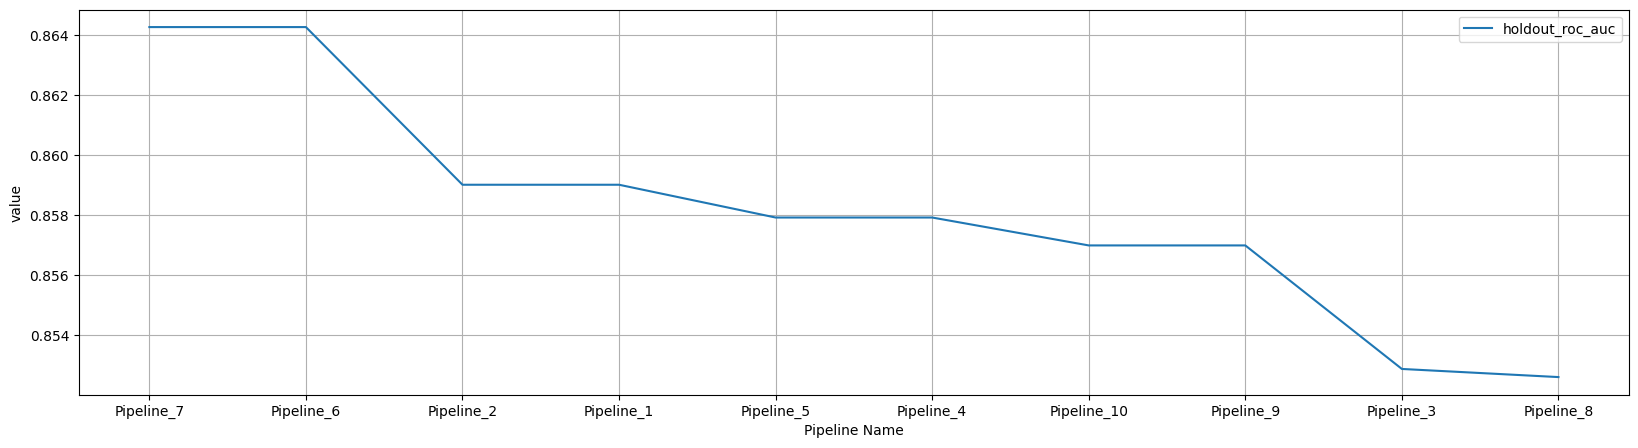

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

pd.options.plotting.backend = "matplotlib"

plt.figure(figsize=(20, 5))
summary.holdout_roc_auc.plot(label="holdout_roc_auc")
plt.ylabel(ylabel="value")
plt.xticks(
    ticks=range(len(summary.holdout_roc_auc)), labels=summary.holdout_roc_auc.index
)
plt.grid()
plt.legend()
plt.show()

### Get selected pipeline model

Download and reconstruct a scikit-learn pipeline model object from the
AutoAI training job.

In [18]:
best_pipeline = pipeline_optimizer.get_pipeline()

Check confusion matrix for selected pipeline.

In [19]:
pipeline_optimizer.get_pipeline_details()["confusion_matrix"]

,fn,fp,tn,tp
true_class,,,,
Risk,63,10,322,104
No Risk,10,63,104,322


Check features importance for selected pipeline.

In [20]:
pipeline_optimizer.get_pipeline_details()["features_importance"]

,features_importance
ExistingCreditsCount,0.1432
OthersOnLoan,0.1210
Telephone,0.1086
CurrentResidenceDuration,0.0838
OwnsProperty,0.0667
LoanAmount,0.0592
EmploymentDuration,0.0586
Age,0.0574
Sex,0.0492
InstallmentPlans,0.0405


### Convert the pipeline model to a Python script and download it

In [21]:
from ibm_watsonx_ai.helpers import pipeline_to_script

pipeline_to_script(best_pipeline)

### Visualize pipeline

In [22]:
best_pipeline.export_to_sklearn_pipeline()

Pipeline(steps=[('featureunion',
  FeatureUnion(transformer_list=[('float32_transform_140395857945200',
    Pipeline(steps=[('numpycolumnselector',
      NumpyColumnSelector(columns=[0,
        1,
        2,
        3,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        12,
        13,
        14,
        15,
        16,
        17,
        18,
        19])),
     ('compressstrings',
      CompressStrings(compress_type='hash',
       dtypes_list=['char_str',
        'int_num',
        'char_str',
        'char_str',
        'char_str',
        'char_st...
    feature_types=None, gamma=None, gpu_id=None,
    grow_policy=None, importance_type='gain',
    interaction_constraints=None, learning_rate=None,
    max_bin=None, max_cat_threshold=None,
    max_cat_to_onehot=None, max_delta_step=None,
    max_depth=3, max_leaves=None, min_child_weight=1,
    missing=nan, monotone_constraints=None,
    multi_strategy=None, n_estimators=100, n_jobs=4,
    nthread=None, ...))])

Each node in the visualization is a machine-learning operator
(transformer or estimator). Each edge indicates data flow (transformed
output from one operator becomes input to the next).  The input to the
root nodes is the initial dataset and the output from the sink node
is the final prediction.  When you hover the mouse pointer over a
node, a tooltip shows you the configuration arguments of the
corresponding operator (tuned hyperparameters). When you click on the
hyperlink of a node, it brings you to a documentation page for the
operator.

### Pipeline source code

In [23]:
best_pipeline.pretty_print(ipython_display=True)

```python
from autoai_libs.transformers.exportable import NumpyColumnSelector
from autoai_libs.transformers.exportable import CompressStrings
from autoai_libs.transformers.exportable import NumpyReplaceMissingValues
from autoai_libs.transformers.exportable import NumpyReplaceUnknownValues
from autoai_libs.transformers.exportable import boolean2float
from autoai_libs.transformers.exportable import CatImputer
from autoai_libs.transformers.exportable import CatEncoder
import numpy as np
from autoai_libs.transformers.exportable import float32_transform
from autoai_libs.transformers.exportable import FloatStr2Float
from autoai_libs.transformers.exportable import NumImputer
from autoai_libs.transformers.exportable import OptStandardScaler
from lale.lib.rasl import ConcatFeatures
from autoai_libs.transformers.exportable import NumpyPermuteArray
from xgboost import XGBClassifier
import lale

lale.wrap_imported_operators(
 [
  "autoai_libs.lale.numpy_column_selector",
  "autoai_libs.lale.compress_strings",
  "autoai_libs.lale.numpy_replace_missing_values",
  "autoai_libs.lale.numpy_replace_unknown_values",
  "autoai_libs.lale.boolean2float", "autoai_libs.lale.cat_imputer",
  "autoai_libs.lale.cat_encoder", "autoai_libs.lale.float32_transform",
  "autoai_libs.lale.float_str2_float", "autoai_libs.lale.num_imputer",
  "autoai_libs.lale.opt_standard_scaler",
  "autoai_libs.lale.numpy_permute_array",
 ]
)
numpy_column_selector_0 = NumpyColumnSelector(
 columns=[
  0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
 ]
)
compress_strings = CompressStrings(
 compress_type="hash",
 dtypes_list=[
  "char_str", "int_num", "char_str", "char_str", "char_str", "char_str",
  "int_num", "char_str", "char_str", "int_num", "char_str", "int_num",
  "char_str", "char_str", "int_num", "char_str", "int_num", "char_str",
  "char_str",
 ],
 missing_values_reference_list=["", "-", "?", float("nan")],
 misslist_list=[
  [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [],
  [], [],
 ],
)
numpy_replace_missing_values_0 = NumpyReplaceMissingValues(
 filling_values=float("nan"), missing_values=[]
)
numpy_replace_unknown_values = NumpyReplaceUnknownValues(
 filling_values=float("nan"),
 filling_values_list=[
  float("nan"), float("nan"), float("nan"), float("nan"), float("nan"),
  float("nan"), float("nan"), float("nan"), float("nan"), float("nan"),
  float("nan"), float("nan"), float("nan"), float("nan"), float("nan"),
  float("nan"), float("nan"), float("nan"), float("nan"),
 ],
 missing_values_reference_list=["", "-", "?", float("nan")],
)
cat_imputer = CatImputer(
 missing_values=float("nan"),
 sklearn_version_family="1",
 strategy="most_frequent",
)
cat_encoder = CatEncoder(
 dtype=np.float64,
 handle_unknown="error",
 sklearn_version_family="1",
 encoding="ordinal",
 categories="auto",
)
numpy_column_selector_1 = NumpyColumnSelector(columns=[4])
float_str2_float = FloatStr2Float(
 dtypes_list=["int_num"], missing_values_reference_list=[]
)
numpy_replace_missing_values_1 = NumpyReplaceMissingValues(
 filling_values=float("nan"), missing_values=[]
)
num_imputer = NumImputer(missing_values=float("nan"), strategy="median")
opt_standard_scaler = OptStandardScaler(use_scaler_flag=False)
numpy_permute_array = NumpyPermuteArray(
 axis=0,
 permutation_indices=[
  0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 4,
 ],
)
xgb_classifier = XGBClassifier(
 max_depth=3,
 min_child_weight=1,
 missing=float("nan"),
 n_estimators=100,
 n_jobs=4,
 random_state=33,
 tree_method="hist",
 verbosity=0,
 silent=True,
)
pipeline = (
 (
  (
   numpy_column_selector_0
   >> compress_strings
   >> numpy_replace_missing_values_0
   >> numpy_replace_unknown_values
   >> boolean2float()
   >> cat_imputer
   >> cat_encoder
   >> float32_transform()
  )
  & (
   numpy_column_selector_1
   >> float_str2_float
   >> numpy_replace_missing_values_1
   >> num_imputer
   >> opt_standard_scaler
   >> float32_transform()
  )
 )
 >> ConcatFeatures()
 >> numpy_permute_array
 >> xgb_classifier
)
```

In the pretty-printed code, `>>` is the pipe combinator (dataflow
edge) and `&` is the and combinator (combining multiple subpipelines).
They correspond to the `make_pipeline` and `make_union` functions from
scikit-learn, respectively. If you prefer the functions, you can
instead pretty-print your pipeline with
`best_pipeline.pretty_print(ipython_display=True, combinators=False)`.

### Reading training data

In [24]:
train_df = pipeline_optimizer.get_data_connections()[0].read()

train_X = train_df.drop(["Risk"], axis=1).values
train_y = train_df.Risk.values

### Test pipeline model locally

In [25]:
predicted_y = best_pipeline.predict(train_X)
predicted_y[:5]

array(['No Risk', 'No Risk', 'No Risk', 'No Risk', 'No Risk'],
   dtype=object)

<a id="5.-Historical-runs"></a>
## 5. Historical runs

In this section you learn to work with historical AutoPipelines fit jobs (runs).

To list historical runs use method `list()`. You can filter runs by providing experiment name.

In [26]:
experiment.runs(filter="Credit Risk Prediction - AutoAI").list()

,timestamp,run_id,state,auto_pipeline_optimizer name
0,2026-04-24T10:06:22.542Z,ff648f7c-4628-4646-a0c5-b468ebc1a5d6,completed,Credit Risk Prediction - AutoAI
1,2026-04-24T10:00:37.835Z,dbd7ea48-35fa-4193-b27e-a45f4cf1c297,completed,Credit Risk Prediction - AutoAI
2,2026-04-24T09:52:10.529Z,108417d0-0eb0-4735-ab10-87f8be368688,completed,Credit Risk Prediction - AutoAI
3,2026-04-24T09:40:03.432Z,dbe2e9c6-35eb-4ef7-8655-037520b9d55c,completed,Credit Risk Prediction - AutoAI


To work with historical pipelines found during a particular optimizer
run, you need to first provide the `run_id` to select the fitted
optimizer.

**Note**: you can assign selected `run_id` to the run_id variable.

In [27]:
run_id = run_details["metadata"]["id"]

### Get executed optimizer's configuration parameters

In [28]:
experiment.runs(filter="Credit Risk Prediction - AutoAI").get_params(run_id=run_id)

{'name': 'Credit Risk Prediction - AutoAI',
 'desc': 'Sample notebook',
 'prediction_type': 'binary',
 'prediction_column': 'Risk',
 'prediction_columns': None,
 'timestamp_column_name': None,
 'holdout_size': None,
 'max_num_daub_ensembles': None,
 't_shirt_size': 'c076e82c-b2a7-4d20-9c0f-1f0c2fdf5a24',
 'include_only_estimators': None,
 'cognito_transform_names': None,
 'train_sample_rows_test_size': None,
 'text_processing': None,
 'train_sample_columns_index_list': None,
 'daub_give_priority_to_runtime': None,
 'positive label': None,
 'incremental_learning': None,
 'early_stop_enabled': None,
 'early_stop_window_size': None,
 'outliers_columns': None,
 'numerical_columns': None,
 'categorical_columns': None,
 'time_ordered_data': None,
 'feature_selector_mode': None,
 'test_data_csv_separator': ',',
 'test_data_excel_sheet': None,
 'test_data_encoding': 'utf-8',
 'drop_duplicates': True,
 'csv_separator': ',',
 'excel_sheet': None,
 'encoding': 'utf-8',
 'retrain_on_holdout': True


### Get historical optimizer instance and training details

In [29]:
historical_opt = experiment.runs.get_optimizer(run_id)

In [30]:
run_details = historical_opt.get_run_details()

### List trained pipelines for selected optimizer

In [31]:
historical_opt.summary()

,Enhancements,Estimator,training_roc_auc_(optimized),holdout_average_precision,holdout_log_loss,training_accuracy,holdout_roc_auc,training_balanced_accuracy,training_f1,holdout_precision,training_average_precision,training_log_loss,holdout_recall,training_precision,holdout_accuracy,holdout_balanced_accuracy,training_recall,holdout_f1
Pipeline Name,,,,,,,,,,,,,,,,,,
Pipeline_7,HPO,XGBClassifier,0.841589,0.460442,0.322346,0.792548,0.864259,0.742720,0.851366,0.836364,0.909047,0.449861,0.969880,0.812676,0.853707,0.796317,0.893956,0.898187
Pipeline_6,,XGBClassifier,0.841589,0.460442,0.322346,0.792548,0.864259,0.742720,0.851366,0.836364,0.909047,0.449861,0.969880,0.812676,0.853707,0.796317,0.893956,0.898187
Pipeline_2,HPO,SnapBoostingMachineClassifier,0.849033,0.462044,0.357500,0.758198,0.859011,0.749366,0.810154,0.888545,0.913354,0.459816,0.864458,0.847255,0.837675,0.824444,0.776176,0.876336
Pipeline_1,,SnapBoostingMachineClassifier,0.849033,0.462044,0.357500,0.758198,0.859011,0.749366,0.810154,0.888545,0.913354,0.459816,0.864458,0.847255,0.837675,0.824444,0.776176,0.876336
Pipeline_5,"HPO, FE, HPO, Ensemble",BatchedTreeEnsembleClassifier(SnapBoostingMach...,0.846691,0.475690,0.421992,0.753289,0.857920,0.748640,0.804304,0.852090,0.911480,0.475742,0.798193,0.850667,0.773547,0.761372,0.762750,0.824261
Pipeline_4,"HPO, FE, HPO",SnapBoostingMachineClassifier,0.846691,0.475690,0.421992,0.753289,0.857920,0.748640,0.804304,0.852090,0.911480,0.475742,0.798193,0.850667,0.773547,0.761372,0.762750,0.824261
Pipeline_10,"HPO, FE, HPO, Ensemble",BatchedTreeEnsembleClassifier(XGBClassifier),0.849874,0.477831,0.420076,0.793440,0.856991,0.744547,0.851809,0.812332,0.913753,0.440680,0.912651,0.814339,0.801603,0.746744,0.892953,0.859574
Pipeline_9,"HPO, FE, HPO",XGBClassifier,0.849874,0.477831,0.420076,0.793440,0.856991,0.744547,0.851809,0.812332,0.913753,0.440680,0.912651,0.814339,0.801603,0.746744,0.892953,0.859574
Pipeline_3,"HPO, FE",SnapBoostingMachineClassifier,0.844684,0.473553,0.405801,0.751507,0.852879,0.745651,0.803318,0.849057,0.910099,0.474168,0.813253,0.847617,0.779559,0.762914,0.763424,0.830769


### Get selected pipeline and test locally

In [32]:
hist_pipeline = historical_opt.get_pipeline(pipeline_name="Pipeline_3")

In [33]:
predicted_y = hist_pipeline.predict(train_X)
predicted_y[:5]

array(['No Risk', 'No Risk', 'No Risk', 'No Risk', 'No Risk'],
   dtype='<U32')

---

<a id="6.-Pipeline-refinement-with-Lale-and-testing"></a>
## 6. Pipeline refinement with Lale and testing

In this section you learn how to refine and retrain the best
pipeline returned by AutoAI. There are many ways to refine a pipeline.
For illustration, simply replace the final estimator in the
pipeline by an interpretable model. The call to
`wrap_imported_operators()` augments scikit-learn operators with
schemas for hyperparameter tuning.

In [34]:
from lale import wrap_imported_operators
from lale.lib.lale import Hyperopt
from sklearn.linear_model import LogisticRegression as LR
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.tree import DecisionTreeClassifier as Tree

wrap_imported_operators()

### Pipeline decomposition and new definition

Start by removing the last step of the pipeline, i.e., the final estimator.

In [35]:
prefix = hist_pipeline.remove_last().freeze_trainable()
prefix.export_to_sklearn_pipeline()

Pipeline(steps=[('featureunion',
  FeatureUnion(transformer_list=[('float32_transform_140397642906032',
    Pipeline(steps=[('numpycolumnselector',
      NumpyColumnSelector(columns=[0,
        1,
        2,
        3,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        12,
        13,
        14,
        15,
        16,
        17,
        18,
        19])),
     ('compressstrings',
      CompressStrings(compress_type='hash',
       dtypes_list=['char_str',
        'int_num',
        'char_str',
        'char_str',
        'char_str',
        'char_st...
  autoai_libs.cognito.transforms.transform_utils.TA1(fun = numpy.square, name = 'square', datatypes = ['numeric'], feat_constraints = [<cyfunction is_not_categorical at 0x7fb07d602750>], tgraph = None, apply_all = True, col_names = ['CheckingStatus', 'LoanDuration', 'CreditHistory', 'LoanPurpose', 'LoanAmount', 'ExistingSavings', 'EmploymentDuration', 'InstallmentPercent', 'Sex', 'OthersOnLoan', 'CurrentResidenceDuration', 'OwnsProperty', 'Age', 'InstallmentPlans', 'Housing', 'ExistingCreditsCount', 'Job', 'Dependents', 'Telephone', 'ForeignWorker', 'sum(LoanDuration__LoanAmount)', 'sum(LoanDuration__Age)', 'sum(LoanAmount__Age)'], col_dtypes = [dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32')], col_as_json_objects = None)),
 ('fs1-2',
  autoai_libs.cognito.transforms.transform_utils.FS1(cols_ids_must_keep = range(0, 20), additional_col_count_to_keep = 20, ptype = 'classification'))])

Next, add a new final step, which consists of a choice of three
estimators. In this code, `|` is the or combinator (algorithmic
choice). It defines a search space for another optimizer run.

In [36]:
new_pipeline = prefix >> (LR | Tree | KNN)

### New optimizer `Hyperopt` configuration and training

To automatically select the algorithm and tune its hyperparameters, we
create an instance of the `Hyperopt` optimizer and `fit` it to the
data.

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train_X, train_y, test_size=0.15, random_state=33
)

In [38]:
hyperopt = Hyperopt(estimator=new_pipeline, cv=3, max_evals=20, scoring="roc_auc")
hyperopt_pipelines = hyperopt.fit(X_train, y_train)

100%|██████████| 20/20 [00:30<00:00,  1.53s/trial, best loss: -0.7945246342082073]
2 out of 20 trials failed, call summary() for details.
Run with verbose=True to see per-trial exceptions.


In [39]:
pipeline_model = hyperopt_pipelines.get_pipeline()

### Pipeline model tests and visualization

In [40]:
from sklearn.metrics import roc_auc_score

predicted_y = pipeline_model.predict(X_test)
score = roc_auc_score(predicted_y == "Risk", y_test == "Risk")
print(f"roc_auc_score {score:.1%}")

roc_auc_score 74.7%


In [41]:
pipeline_model.export_to_sklearn_pipeline()

Pipeline(steps=[('featureunion',
  FeatureUnion(transformer_list=[('float32_transform_140397643004864',
    Pipeline(steps=[('numpycolumnselector',
      NumpyColumnSelector(columns=[0,
        1,
        2,
        3,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        12,
        13,
        14,
        15,
        16,
        17,
        18,
        19])),
     ('compressstrings',
      CompressStrings(compress_type='hash',
       dtypes_list=['char_str',
        'int_num',
        'char_str',
        'char_str',
        'char_str',
        'char_st...
  autoai_libs.cognito.transforms.transform_utils.TA1(fun = numpy.square, name = 'square', datatypes = ['numeric'], feat_constraints = [<cyfunction is_not_categorical at 0x7fb07d602750>], tgraph = None, apply_all = True, col_names = ['CheckingStatus', 'LoanDuration', 'CreditHistory', 'LoanPurpose', 'LoanAmount', 'ExistingSavings', 'EmploymentDuration', 'InstallmentPercent', 'Sex', 'OthersOnLoan', 'CurrentResidenceDuration', 'OwnsProperty', 'Age', 'InstallmentPlans', 'Housing', 'ExistingCreditsCount', 'Job', 'Dependents', 'Telephone', 'ForeignWorker', 'sum(LoanDuration__LoanAmount)', 'sum(LoanDuration__Age)', 'sum(LoanAmount__Age)'], col_dtypes = [dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32')], col_as_json_objects = None)),
 ('fs1-2',
  autoai_libs.cognito.transforms.transform_utils.FS1(cols_ids_must_keep = range(0, 20), additional_col_count_to_keep = 20, ptype = 'classification')),
 ('decisiontreeclassifier',
  DecisionTreeClassifier(max_features=0.810695630371689,
    min_samples_leaf=0.10843483792853714,
    min_samples_split=0.3084610330532765))])

<a id="7.-Deploy-and-Score"></a>
## 7. Deploy and Score

In this section you will learn how to deploy and score pipeline model as webservice and batch using WML instance.

### Webservice deployment creation

In [42]:
from ibm_watsonx_ai.deployment import WebService

service = WebService(credentials, source_space_id=space_id)

service.create(
    experiment_run_id=run_id,
    model="Pipeline_1",
    deployment_name="Credit Risk Deployment AutoAI",
)

Preparing an AutoAI Deployment...
Published model uid: 2076bcb3-f22c-44b0-95b4-a9595162fb7e
Deploying model 2076bcb3-f22c-44b0-95b4-a9595162fb7e using V4 client.


######################################################################################

Synchronous deployment creation for id: '2076bcb3-f22c-44b0-95b4-a9595162fb7e' started

######################################################################################


initializing
Note: online_url is deprecated and will be removed in a future release. Use serving_urls instead.
.....
ready


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='3b9b1624-7aaf-457e-918c-28a2d83e4ac9'
-----------------------------------------------------------------------------------------------




Deployment object could be printed to show basic information:

In [43]:
print(service)

To show all available information about the deployment use the `.get_params()` method:

In [44]:
service.get_params()

### Scoring of webservice
You can make scoring request by calling `score()` on deployed pipeline.

In [45]:
predictions = service.score(payload=train_df.drop(["Risk"], axis=1).iloc[:10])
predictions

{'predictions': [{'fields': ['prediction', 'probability'],
   'values': [['No Risk', [0.7463715340362654, 0.25362846596373456]],
 ['No Risk', [0.8389065655314143, 0.16109343446858565]],
 ['No Risk', [0.6893342531092224, 0.3106657468907776]],
 ['No Risk', [0.9696291530429875, 0.030370846957012546]],
 ['No Risk', [0.7115231805320016, 0.2884768194679984]],
 ['No Risk', [0.8198532531594086, 0.18014674684059143]],
 ['No Risk', [0.9827794374874906, 0.01722056251250941]],
 ['No Risk', [0.9484906034736605, 0.051509396526339485]],
 ['No Risk', [0.836971951542384, 0.163028048457616]],
 ['No Risk', [0.8468729998757115, 0.15312700012428848]]]}]}

If you want to work with the web service in an external Python application, you can retrieve the service object:
 - Initialize the service using `service = WebService(wml_credentials)`
 - Get deployment_id using the `service.list()` method
 - Get webservice object using the `service.get('deployment_id')` method

After that you can call `service.score()` method.

### Deleting deployment
You can delete the existing deployment by calling the `service.delete()` command.
To list the existing web services you can use `service.list()`.

### Batch deployment creation

A batch deployment processes input data from a inline data and return predictions in scoring details or processes from data asset and writes the output to a file.

In [46]:
batch_payload_df = train_df.drop(["Risk"], axis=1)[:5]
batch_payload_df

,CheckingStatus,LoanDuration,CreditHistory,LoanPurpose,LoanAmount,ExistingSavings,EmploymentDuration,InstallmentPercent,Sex,OthersOnLoan,CurrentResidenceDuration,OwnsProperty,Age,InstallmentPlans,Housing,ExistingCreditsCount,Job,Dependents,Telephone,ForeignWorker
0,less_0,18,credits_paid_to_date,car_new,462,less_100,1_to_4,2,female,none,2,savings_insurance,37,stores,own,2,skilled,1,none,yes
1,less_0,15,prior_payments_delayed,furniture,250,less_100,1_to_4,2,male,none,3,real_estate,28,none,own,2,skilled,1,yes,no
2,less_0,16,credits_paid_to_date,vacation,3109,less_100,4_to_7,3,female,none,1,car_other,36,none,own,2,skilled,1,none,yes
3,less_0,5,all_credits_paid_back,car_new,1523,less_100,unemployed,2,female,none,2,real_estate,19,none,rent,1,management_self-employed,1,none,yes
4,less_0,9,all_credits_paid_back,car_used,4302,less_100,1_to_4,3,male,none,1,car_other,34,none,free,1,skilled,1,none,yes


Create batch deployment for `Pipeline_2` created in AutoAI experiment with the `run_id`.

In [47]:
from ibm_watsonx_ai.deployment import Batch

service_batch = Batch(credentials, source_space_id=space_id)
service_batch.create(
    experiment_run_id=run_id,
    model="Pipeline_2",
    deployment_name="Credit Risk Batch Deployment AutoAI",
)

Preparing an AutoAI Deployment...
Published model uid: 7de30e5c-ddfe-4750-888e-0929d1ba4044
Deploying model 7de30e5c-ddfe-4750-888e-0929d1ba4044 using V4 client.


######################################################################################

Synchronous deployment creation for id: '7de30e5c-ddfe-4750-888e-0929d1ba4044' started

######################################################################################


ready
Note: The `/text/generation` and `/text/generation_stream` endpoints will be deprecated in an upcoming release and removed in a future release.
.


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='43e65e10-c23d-4ba4-8f34-2a653aaaebdf'
-----------------------------------------------------------------------------------------------




### Score batch deployment with inline payload as pandas DataFrame.

In [48]:
scoring_params = service_batch.run_job(payload=batch_payload_df, background_mode=False)

Note: The `/text/generation` and `/text/generation_stream` endpoints will be deprecated in an upcoming release and removed in a future release.


##########################################################################

Synchronous scoring for id: '95e45e67-101a-49db-b49f-96f8b51b6779' started

##########################################################################


queued..
completed
Scoring job  '95e45e67-101a-49db-b49f-96f8b51b6779' finished successfully.


In [49]:
scoring_params["entity"]["scoring"].get("predictions")

[{'fields': ['prediction', 'probability'],
  'values': [['No Risk', [0.7463715340362654, 0.25362846596373456]],
   ['No Risk', [0.8389065655314143, 0.16109343446858565]],
   ['No Risk', [0.6893342531092224, 0.3106657468907776]],
   ['No Risk', [0.9696291530429875, 0.030370846957012546]],
   ['No Risk', [0.7115231805320016, 0.2884768194679984]]]}]

### Score batch deployment with payload as connected asset.

Simmilary to training use created connection in order to locate tabe in used database.

In [50]:
from ibm_watsonx_ai.helpers.connections import DeploymentOutputAssetLocation

batch_payload_filename = "credit_risk_batch_payload.csv"
batch_payload_df.to_csv(batch_payload_filename, index=False)

asset_details = client.data_assets.create(
    name=batch_payload_filename, file_path=batch_payload_filename
)
asset_id = client.data_assets.get_id(asset_details)

payload_reference = DataConnection(data_asset_id=asset_id)
results_reference = DataConnection(
    location=DeploymentOutputAssetLocation(name="batch_output_credit_risk.csv")
)

Creating data asset...
SUCCESS


Run scoring job for batch deployment.

In [51]:
scoring_params = service_batch.run_job(
    payload=[payload_reference],
    output_data_reference=results_reference,
    background_mode=False,
)

Note: The `/text/generation` and `/text/generation_stream` endpoints will be deprecated in an upcoming release and removed in a future release.


##########################################################################

Synchronous scoring for id: 'b8a07a6f-8020-4468-b8d7-e33207d971d6' started

##########################################################################


queued..
running
completed
Scoring job  'b8a07a6f-8020-4468-b8d7-e33207d971d6' finished successfully.


### Deleting batch deployment
You can delete the existing deployment by calling the `service_batch.delete()` command.
To list the existing: 
- batch services you can use `service_batch.list()`, 
- scoring jobs you can use `service_batch.list_jobs()`.

<a id="8.-Cleanup"></a>
## 8. Cleanup

If you want to clean up all created assets:
- experiments
- trainings
- pipelines
- model definitions
- models
- functions
- deployments

please follow up this sample [notebook](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.4/notebooks/python_sdk/instance-management/Machine%20Learning%20artifacts%20management.ipynb).

<a id="9.-Summary-and-next-steps"></a>
## 9. Summary and next steps

You successfully completed this notebook!
 
You learned how to use `ibm-watsonx-ai` to run AutoAI experiments. 

Check out our _<a href="https://ibm.github.io/watsonx-ai-python-sdk/samples.html" target="_blank" rel="noopener no referrer">Online Documentation</a>_ for more samples, tutorials, documentation, how-tos, and blog posts. 

### Authors and Maintainers

**Lukasz Cmielowski (Former)**, PhD, Senior Technical Staff Member at IBM watsonx.ai

**Amadeusz Masny (Former)**, Software Engineer at IBM watsonx.ai

**Kiran Kate**, Senior Software Engineer at IBM Research AI

**Martin Hirzel**, Research Staff Member and Manager at IBM Research AI

**Rafał Chrzanowski**, Software Engineer at IBM watsonx.ai

**Maksym Sydorchuk**, Software Engineer at IBM watsonx.ai

Copyright © 2020-2026 IBM. This notebook and its source code are released under the terms of the MIT License.